In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt 

In [12]:
import pandas as pd

data_3 = {
    "producto": ["E", "F", "G", "D", "E", "F", "G", "H", "I", "J"],
    "fecha": pd.to_datetime([
        "2021-06-01", "2021-06-01", "2021-06-02", "2021-06-03", 
        "2021-06-03", "2021-06-04", "2021-06-05", "2021-06-05", 
        "2021-06-06", "2021-06-06"
    ]),
    "categoria": pd.Categorical([
        "Electrónica", "Ropa", "Alimentación", "Electrónica", 
        "Ropa", "Alimentación", "Electrónica", "Ropa", 
        "Alimentación", "Electrónica"
    ]),
    "precio": [120.0, 50.0, 20.0, 150.0, 90.0, 10.0, 200.0, 80.0, 15.0, 130.0],
    "cantidadV": [15, 30, 50, 5, 12, 60, 8, 25, 40, 10],
    "costo": [80, 30, 10, 100, 50, 5, 120, 40, 7, 70],
    "pago": pd.Categorical([
        "Tarjeta de Crédito", "PayPal", "Efectivo", "Tarjeta de Crédito",
        "PayPal", "Efectivo", "Tarjeta de Crédito", "PayPal",
        "Efectivo", "Tarjeta de Crédito"
    ]),
    "ciudad": [
        "Quito", "Cuenca", "Guayaquil", "Loja", 
        "Ambato", "Quito", "Guayaquil", "Cuenca", 
        "Quito", "Loja"
    ]
}

df= pd.DataFrame(data_3)
df['fecha'] = pd.to_datetime(df['fecha'])

print(df.head())
print(df.dtypes)


  producto      fecha     categoria  precio  cantidadV  costo  \
0        E 2021-06-01   Electrónica   120.0         15     80   
1        F 2021-06-01          Ropa    50.0         30     30   
2        G 2021-06-02  Alimentación    20.0         50     10   
3        D 2021-06-03   Electrónica   150.0          5    100   
4        E 2021-06-03          Ropa    90.0         12     50   

                 pago     ciudad  
0  Tarjeta de Crédito      Quito  
1              PayPal     Cuenca  
2            Efectivo  Guayaquil  
3  Tarjeta de Crédito       Loja  
4              PayPal     Ambato  
producto             object
fecha        datetime64[ns]
categoria          category
precio              float64
cantidadV             int64
costo                 int64
pago               category
ciudad               object
dtype: object


# parte 2 
1. arriba dice el tipo
2. listo , desde la definicion del array, para trebajar con metodos de fechas
3. listo en la definicion, mejora el rendimiento porque un objeto ocupa mas recursos

### preguntas
1. para usar metodos de tiempo ,acc4eder a fechas , dias, hora, anios, meses , entre otros
2. la misma pregunta , respondida anteriormente, ayuda a identificar la categoria , valores que se repiten en una columna

# parte 3
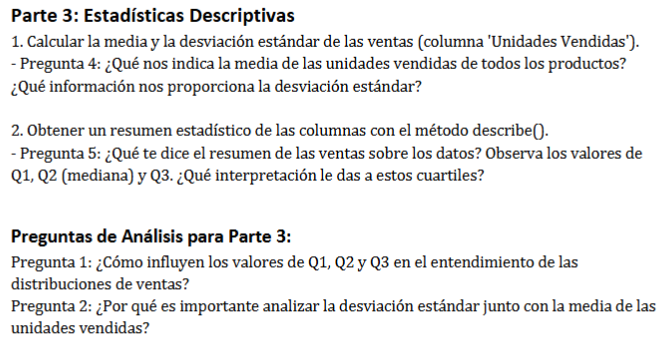



In [13]:
# parte 3
mediaCANTIDAD=df["cantidadV"].mean()
print(" media cantidad \n",mediaCANTIDAD)


df["cantidadV"].describe()

 media cantidad 
 25.5


count    10.000000
mean     25.500000
std      19.091883
min       5.000000
25%      10.500000
50%      20.000000
75%      37.500000
max      60.000000
Name: cantidadV, dtype: float64

1. media un valor representativo de los tados , considerando todos los valores, no verifica la calidad de estos, la desvicion es un promedia de la diferencia de cada valor o dato respecto a la media

2. lo mis importante seria ver donde se concentran los datosm dentro se su escala, Los qurtiles es un valor representativo donde separa los datos de cuarta parte en cuarta parte (4 partes ).

# parte 4

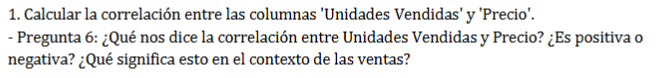

In [14]:
correlacionMatrix=df[["cantidadV","precio"]].corr()

print(correlacionMatrix)

           cantidadV    precio
cantidadV   1.000000 -0.895623
precio     -0.895623  1.000000


1. una correlacion, significa que los valores pueden depender entre si hasta cierto punto, si es positiva si el uno sube el otro tambien , lo mismo si es que baja
2. tiene una relacion negatica ventas y cantidad vendida, por lo que a mayor precio menor ventas:

los indicadores serian:

0 → No hay correlación lineal.

Cerca de 0.1 – 0.3 → Correlación débil.

Cerca de 0.3 – 0.5 → Correlación moderada.

Mayor a 0.5 – 0.7 → Correlación fuerte.

Mayor a 0.7 – 1.0 → Correlación muy fuerte.


# Parte 6
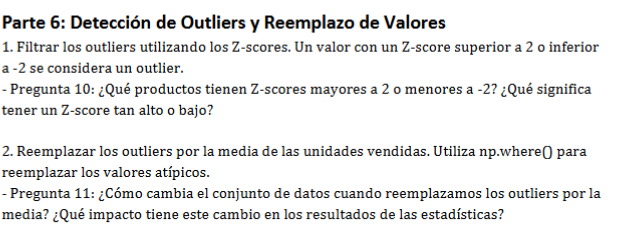

In [ ]:
z_scores=stats.zscore(df["cantidadV"])
print(len(df))
df["cantidadV"]=np.where((z_scores > 2) | (z_scores < -2), mediaCANTIDAD, df["cantidadV"])
print(len(df))


outliers_df_Ventas=df[(z_scores>2)|(z_scores<-2)]



10
10


1. depende , a veces la mediana es mas representativo que la media
2. solo en los numericos por ahora, ya que los de texto usan otro metodos descriptivos

# parte 7

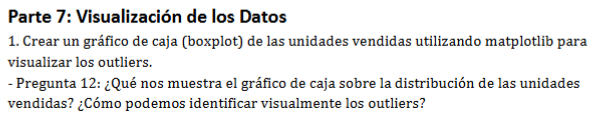

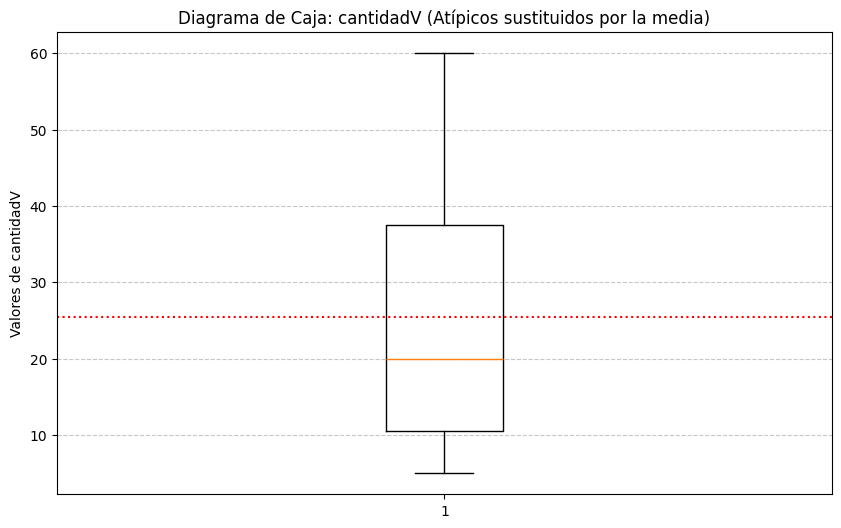

In [22]:


# Crear una figura con dos subgráficos para comparar
plt.figure(figsize=(10, 6))

# Diagrama de caja de la columna ya procesada (sustituida con la media)
plt.boxplot(df["cantidadV"])

# Personalización básica
plt.title("Diagrama de Caja: cantidadV (Atípicos sustituidos por la media)")
plt.ylabel("Valores de cantidadV")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(df["cantidadV"].mean(), color='red', linestyle=':', label='Media')
# plt.axhline(df["cantidadV"].median(), color='blue', linestyle='-', label='Median')

plt.show()


1. en este caso , no hay outlayer, per podramos graficarlos con un `axh line` y le pasamos los valores de los outliers
2. en este caso representa los cuartilas en la escala de los valores de ls datos y muestra su dispersion

1. como dije antes representa los cuartiles (distribucion)
2. los bigotes representan los valores maximos y minimos, el del medio de la caja la media
